# 2. Baseline Models

**Research question.** How do classical, well-understood models (TF-IDF, Logistic Regression, SVM) and a simple ensemble perform on the sentiment classification task? These are the reference points the proposed system (notebook 03) is compared against.

Source table: `backend/results/master_results_table.md` (Part 1a); per-class breakdown: `backend/results/per_class_f1.json`.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd()))
from _common import load_json, show_md, show_fig, show_thesis_fig, metrics_table, RESULTS, FIGURES, DATA
from IPython.display import display
import pandas as pd
pd.set_option('display.max_colwidth', 120)

## 2.1 Headline metrics — full test set (~165k samples)

In [2]:
show_md('master_results_table.md')

# Master Results Table

> Generated automatically from results/ JSON files.

## Part 1 — Classical Ensemble (Full Dataset: 165k test samples)

### 1a. Per-Model Metrics

| Model | Macro-F1 | ECE (raw) | ECE (calibrated) | Temperature |
|-------|----------|-----------|------------------|-------------|
| logreg | 0.6943 | 0.0068 | 0.0074 | 1.031 |
| svm | 0.6817 | 0.0126 | 0.0163 | 1.033 |
| tfidf | 0.6579 | 0.0131 | 0.0174 | 1.131 |
| ensemble | 0.6938 | 0.0216 | 0.0117 | 0.935 |
| meta_learner | 0.6967 | 0.0203 | 0.0230 | 0.984 |

### 1b. Ensemble Optimisation (NSGA-II Multi-Objective)

| Method | Macro-F1 | ECE | Coverage@70% |
|--------|----------|-----|--------------|
| NSGA-II knee (logreg=0.916  svm=0.003  tfidf=0.081) | 0.6940 | 0.0039 | 0.4711 |
| Single-obj PSO (best val) | — | — | — |

### 1c. Neuro-Fuzzy Gating

| Method | Macro-F1 | Accuracy | ECE | Brier |
|--------|----------|----------|-----|-------|
| Uniform ensemble | 0.6938 | 0.6959 | 0.0260 | 0.4123 |
| **Neuro-fuzzy gate** | **0.6955** | 0.6972 | **0.0070** | 0.4076 |
| Δ (NF − uniform) | +0.0017 | — | -0.0190 | -0.0047 |

### 1d. Selective Prediction (Entropy-Gated)

Full ensemble (neuro-fuzzy mode)  F1=0.6949  AURC=0.1521

| τ | Coverage | Accuracy | Macro-F1 |
|---|----------|----------|----------|
| 0.04 | 0.018 | 0.9918 | 0.8618 |
| 0.16 | 0.078 | 0.9852 | 0.9351 |
| 0.28 | 0.140 | 0.9662 | 0.9326 |
| 0.40 | 0.210 | 0.9428 | 0.9151 |
| 0.52 | 0.296 | 0.9162 | 0.8941 |
| 0.64 | 0.404 | 0.8781 | 0.8597 |
| 0.76 | 0.574 | 0.8189 | 0.8083 |
| 0.88 | 0.786 | 0.7552 | 0.7507 |
| 1.00 | 1.000 | 0.6964 | 0.6949 |

### 1e. Coverage-Accuracy (AUCA)

| Rank | Model | AUCA | AUC-F1 | Acc@100% |
|------|-------|------|--------|----------|
| 1 | logreg | 0.8300 | 0.8124 | 0.6957 |
| 2 | svm | 0.8152 | 0.8029 | 0.6835 |
| 3 | tfidf | 0.7975 | 0.7672 | 0.6630 |
| 4 | ensemble | 0.8288 | 0.8135 | 0.6956 |
| 5 | meta_learner | 0.8309 | 0.7479 | 0.6973 |
| 6 | neuro_fuzzy | 0.8304 | 0.8138 | 0.6972 |

---

## Part 2 — Route A: DeBERTa-v3 + Classical (450-sample fine-tune, 180 test)

> ⚠️  Small test set (n=180). Results are directional; full-scale fine-tuning pending GPU access.

### 2a. Per-Model Metrics

| Model | Macro-F1 | ECE (raw) | ECE (calibrated) | Temperature |
|-------|----------|-----------|------------------|-------------|
| deberta_v3 | 0.6579 | 0.1084 | 0.1084 | 1.000 |
| logreg | 0.7544 | 0.0789 | 0.0621 | 0.861 |
| svm | 0.7863 | 0.1004 | 0.0649 | 0.735 |

### 2b. Neuro-Fuzzy Gating

| Method | Macro-F1 | Accuracy | ECE | Brier |
|--------|----------|----------|-----|-------|
| Uniform ensemble | 0.7770 | 0.7778 | 0.1385 | 0.3375 |
| **Neuro-fuzzy gate** | **0.7976** | 0.8000 | **0.0853** | 0.3048 |
| Δ | +0.0206 | — | -0.0532 | -0.0327 |

### 2c. Coverage-Accuracy (AUCA)

| Rank | Model | AUCA | AUC-F1 | Acc@100% |
|------|-------|------|--------|----------|
| 1 | svm | 0.9122 | 0.9095 | 0.7889 |
| 2 | neuro_fuzzy | 0.9070 | 0.9015 | 0.8000 |
| 3 | ensemble_uniform | 0.9048 | 0.9002 | 0.7778 |
| 4 | logreg | 0.9003 | 0.8951 | 0.7556 |
| 5 | deberta_v3 | 0.7125 | 0.5642 | 0.6556 |

---

## Part 3 — Cross-System Comparison

| System | Method | Macro-F1 | ECE | AUCA | Notes |
|--------|--------|----------|-----|------|-------|
| Classical (165k) | logreg | 0.6943 | 0.0068 | — | Full test set |
| Classical (165k) | svm | 0.6817 | 0.0126 | — | Full test set |
| Classical (165k) | tfidf | 0.6579 | 0.0131 | — | Full test set |
| Classical (165k) | ensemble | 0.6938 | 0.0216 | — | Full test set |
| Classical (165k) | meta_learner | 0.6967 | 0.0203 | — | Full test set |
| Classical (165k) | Neuro-fuzzy gate | 0.6955 | 0.0070 | — | Adaptive routing |
| Classical (165k) | NSGA-II ensemble | 0.6940 | 0.0039 | — | Pareto knee-point |
| Route A (450 train) | NF gate (DeBERTa+LogReg+SVM) | 0.7976 | 0.0853 | — | n=180 test, directional |
| Route A (450 train) | Best AUCA (svm) | 0.7889 | — | 0.9122 | n=180 test |

## 2.2 Per-class precision / recall / F1

In [3]:
pcf1 = load_json('per_class_f1.json')
print('n_test =', pcf1['n_test'], ' labels =', pcf1['labels'])
rows = []
for model, res in pcf1['results'].items():
    for label in pcf1['labels']:
        r = res[label]
        rows.append({'model': model, 'label': label, **r, 'macro_f1': res['macro_f1']})
pd.DataFrame(rows).set_index(['model', 'label'])

n_test = 20000  labels = ['Positive', 'Neutral', 'Negative']


precision  recall      f1  macro_f1
model        label                                        
logreg       Positive     0.7758  0.7267  0.7504    0.6943
             Neutral      0.6239  0.6261  0.6250    0.6943
             Negative     0.6889  0.7268  0.7073    0.6943
svm          Positive     0.7584  0.7226  0.7401    0.6817
             Neutral      0.6108  0.6055  0.6081    0.6817
             Negative     0.6800  0.7144  0.6968    0.6817
tfidf        Positive     0.7701  0.6827  0.7237    0.6579
             Neutral      0.6184  0.5201  0.5650    0.6579
             Negative     0.6188  0.7669  0.6849    0.6579
ensemble     Positive     0.7774  0.7237  0.7496    0.6938
             Neutral      0.6303  0.6162  0.6231    0.6938
             Negative     0.6817  0.7378  0.7087    0.6938
meta_learner Positive     0.7766  0.7312  0.7532    0.6967
             Neutral      0.6158  0.6496  0.6322    0.6967
             Negative     0.7023  0.7070  0.7046    0.6967
pso          Positive     0.7802  0.7253  0.7518    0.6951
             Neutral      0.6284  0.6236  0.6260    0.6951
             Negative     0.6842  0.7327  0.7076    0.6951
nsga2        Positive     0.7791  0.7262  0.7517    0.6949
             Neutral      0.6260  0.6241  0.6251    0.6949
             Negative     0.6863  0.7306  0.7078    0.6949
neuro_fuzzy  Positive     0.7839  0.7234  0.7524    0.6955
             Neutral      0.6297  0.6202  0.6249    0.6955
             Negative     0.6819  0.7388  0.7092    0.6955
ts_meta      Positive     0.7766  0.7312  0.7532    0.6967
             Neutral      0.6158  0.6496  0.6322    0.6967
             Negative     0.7023  0.7070  0.7046    0.6967

## 2.3 Confusion matrices

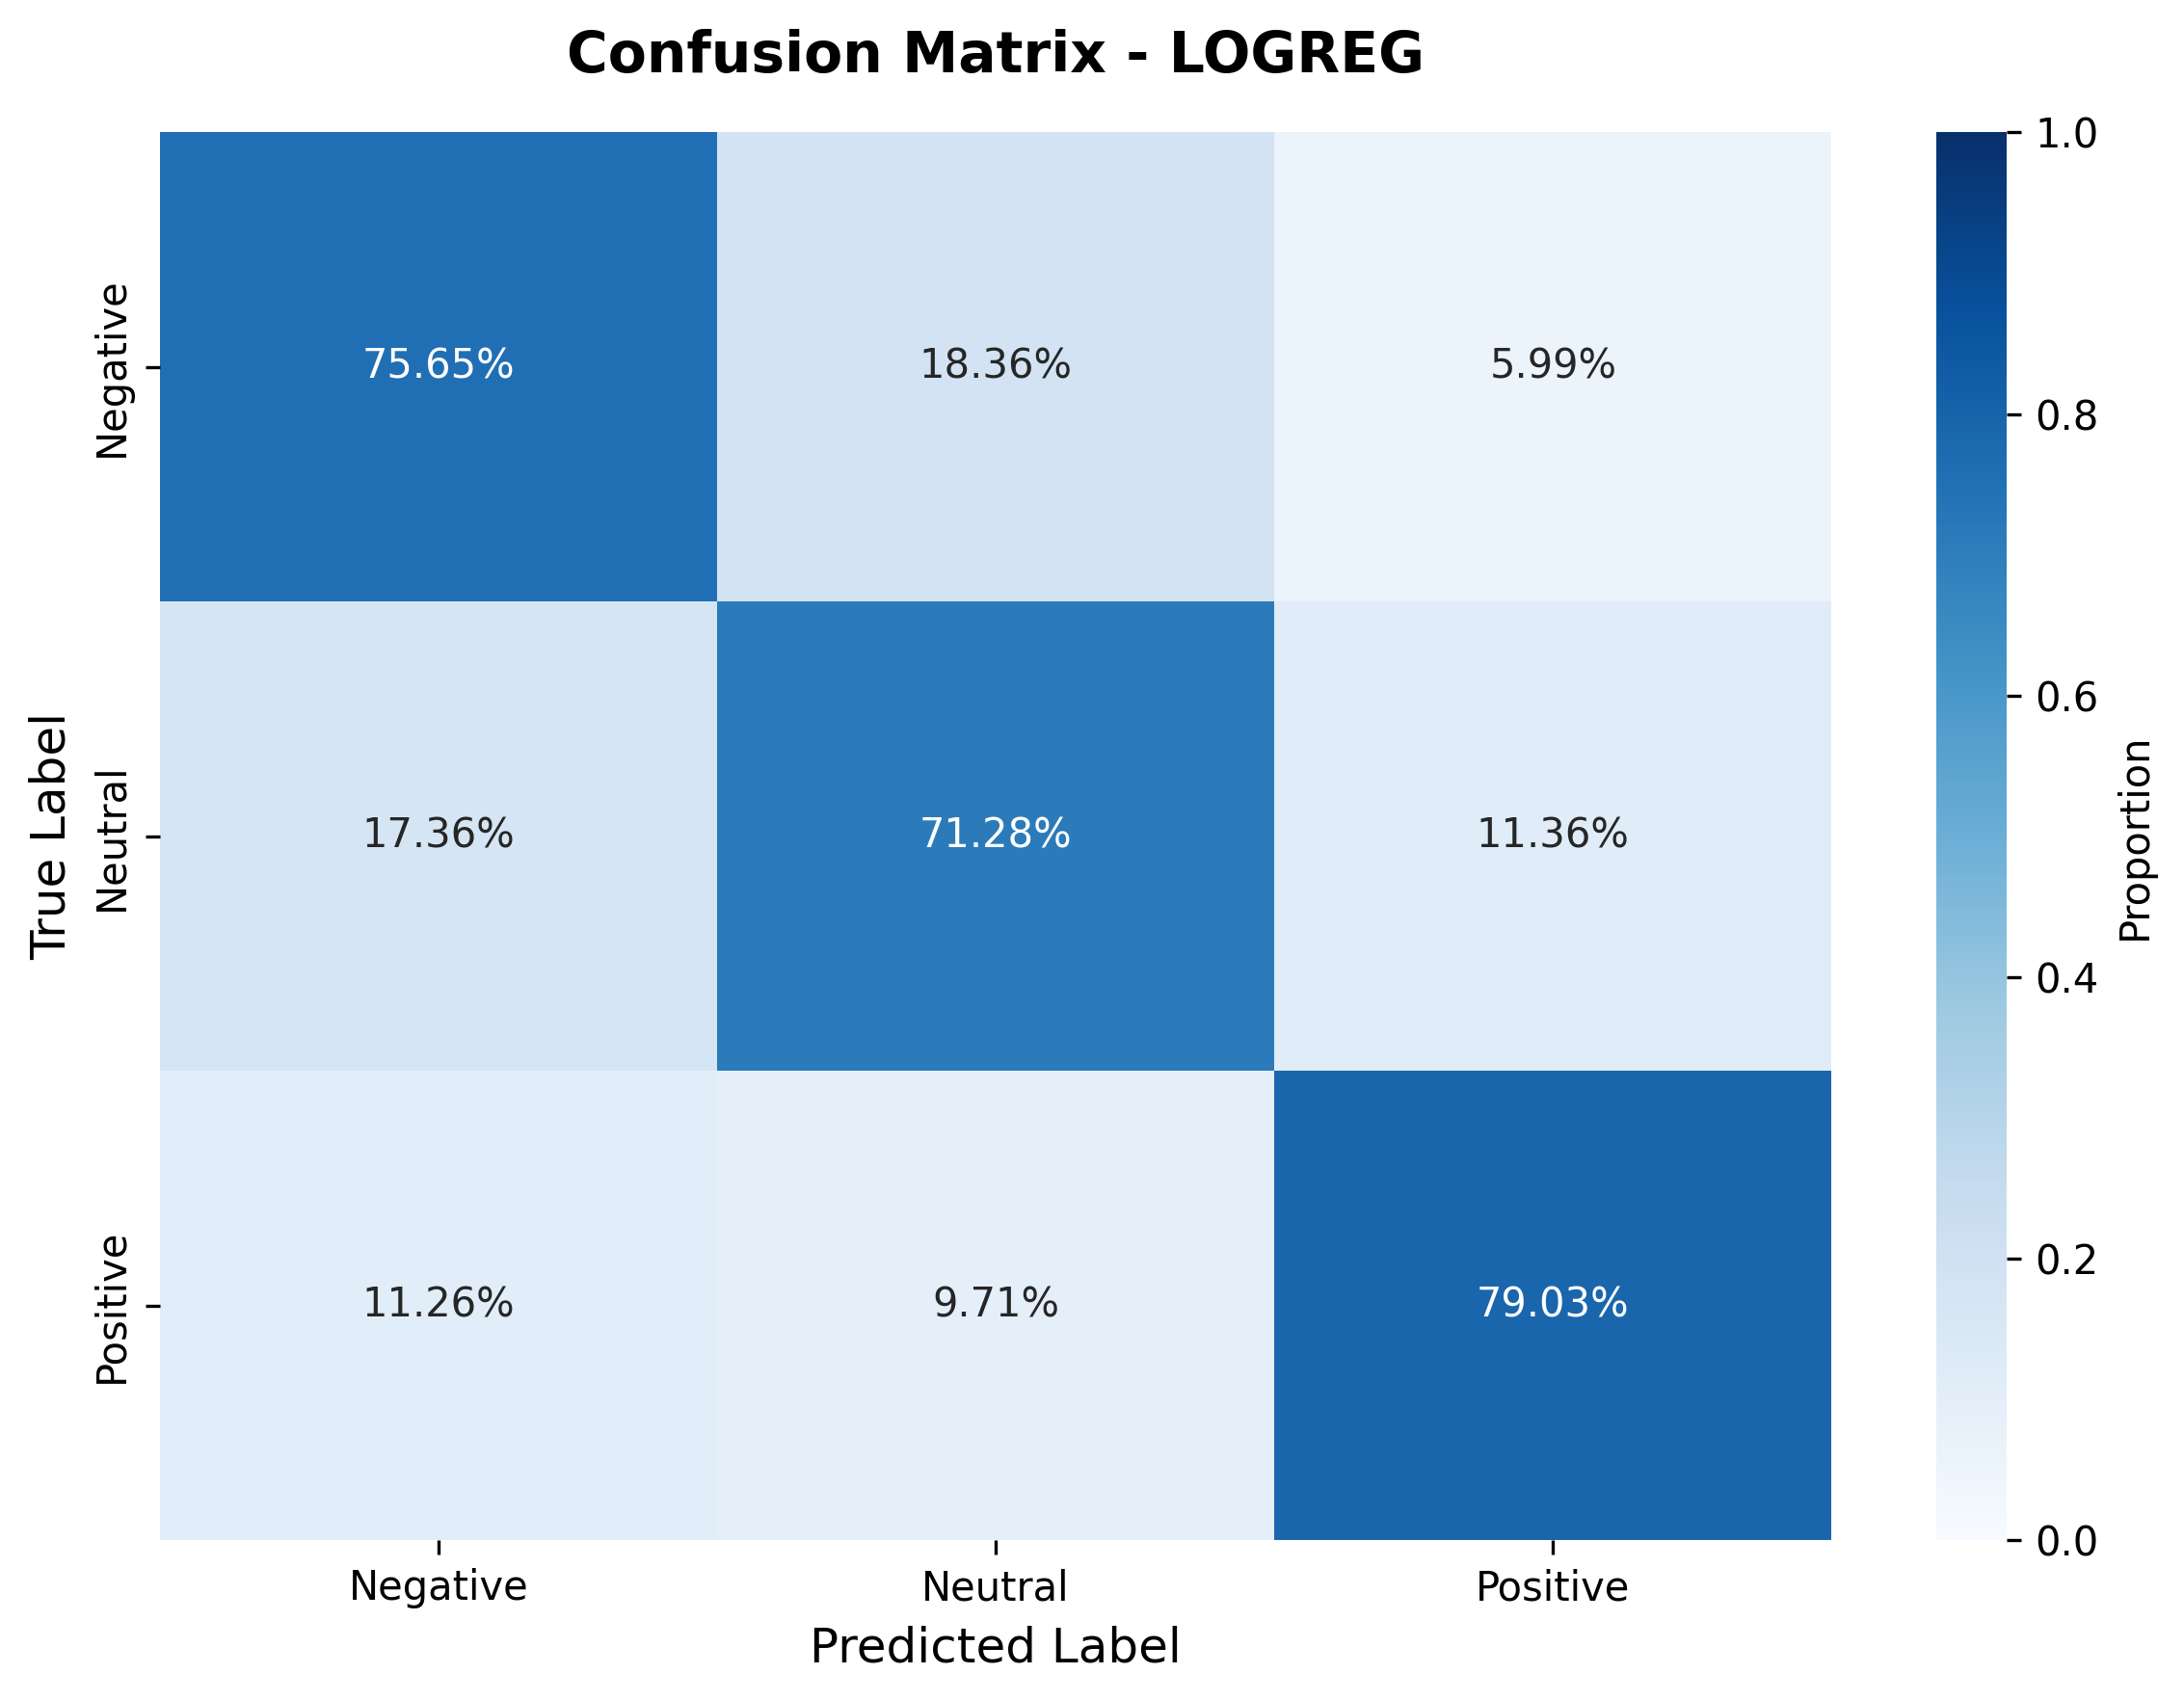

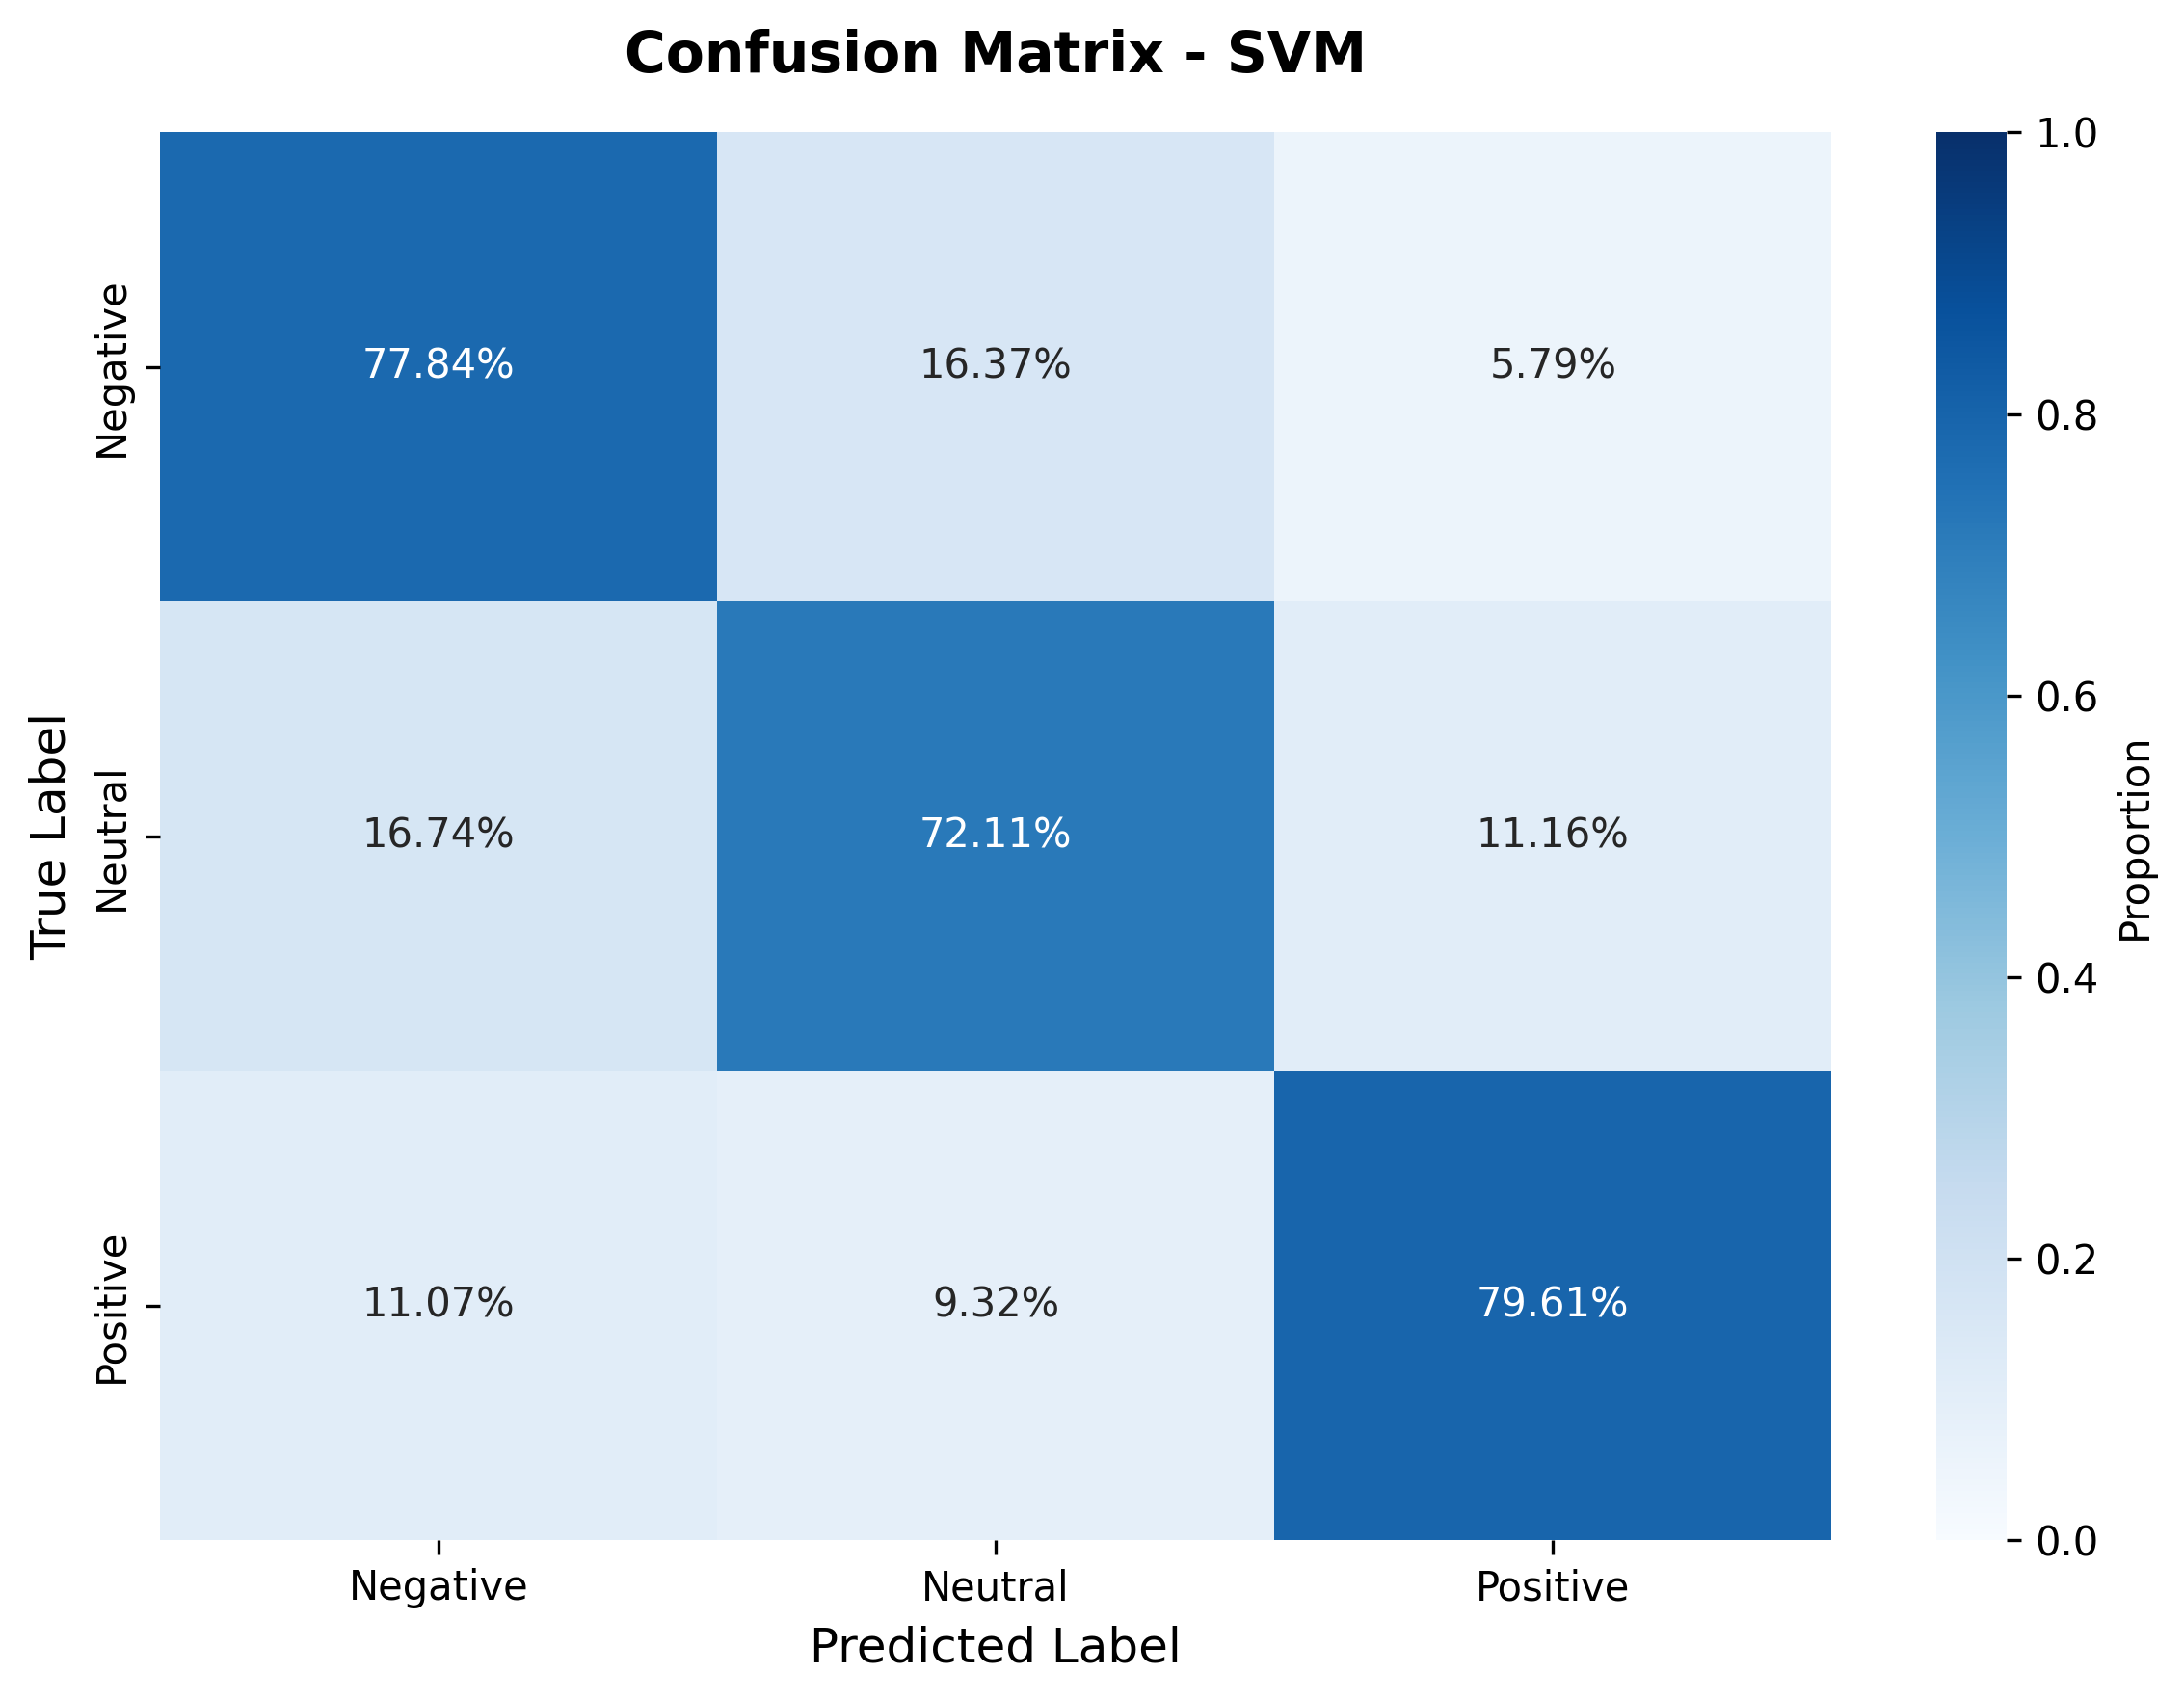

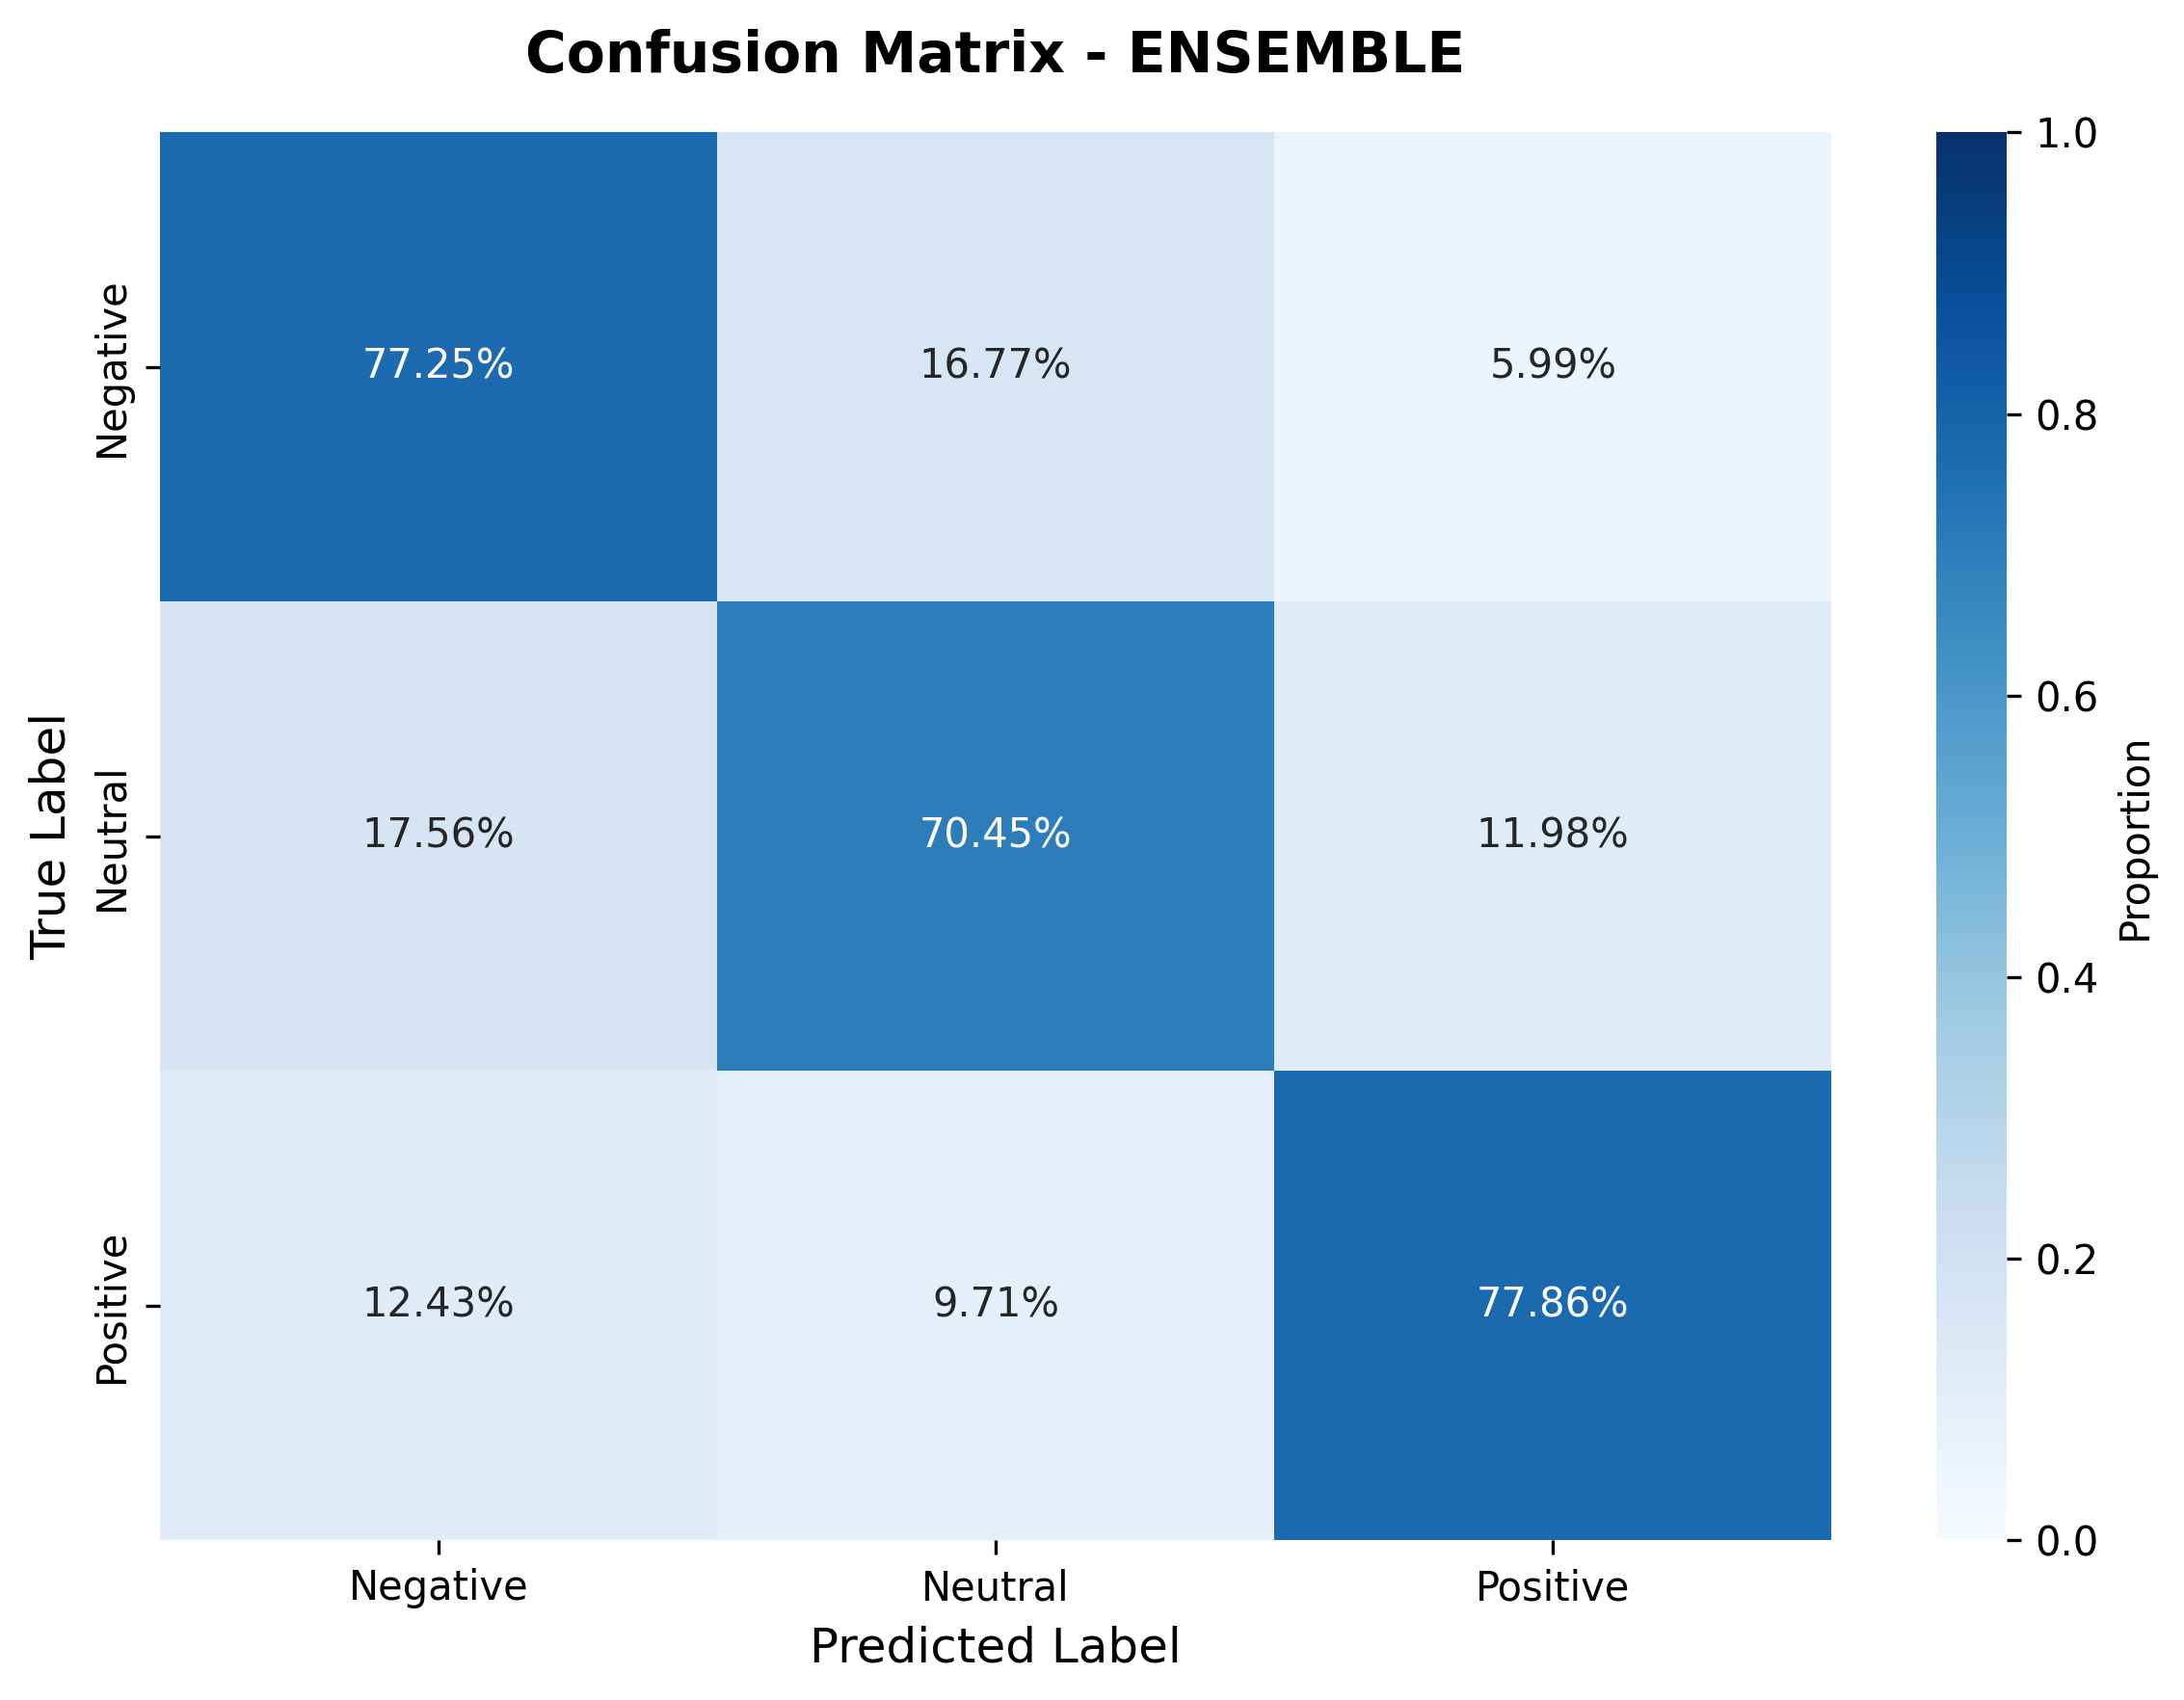

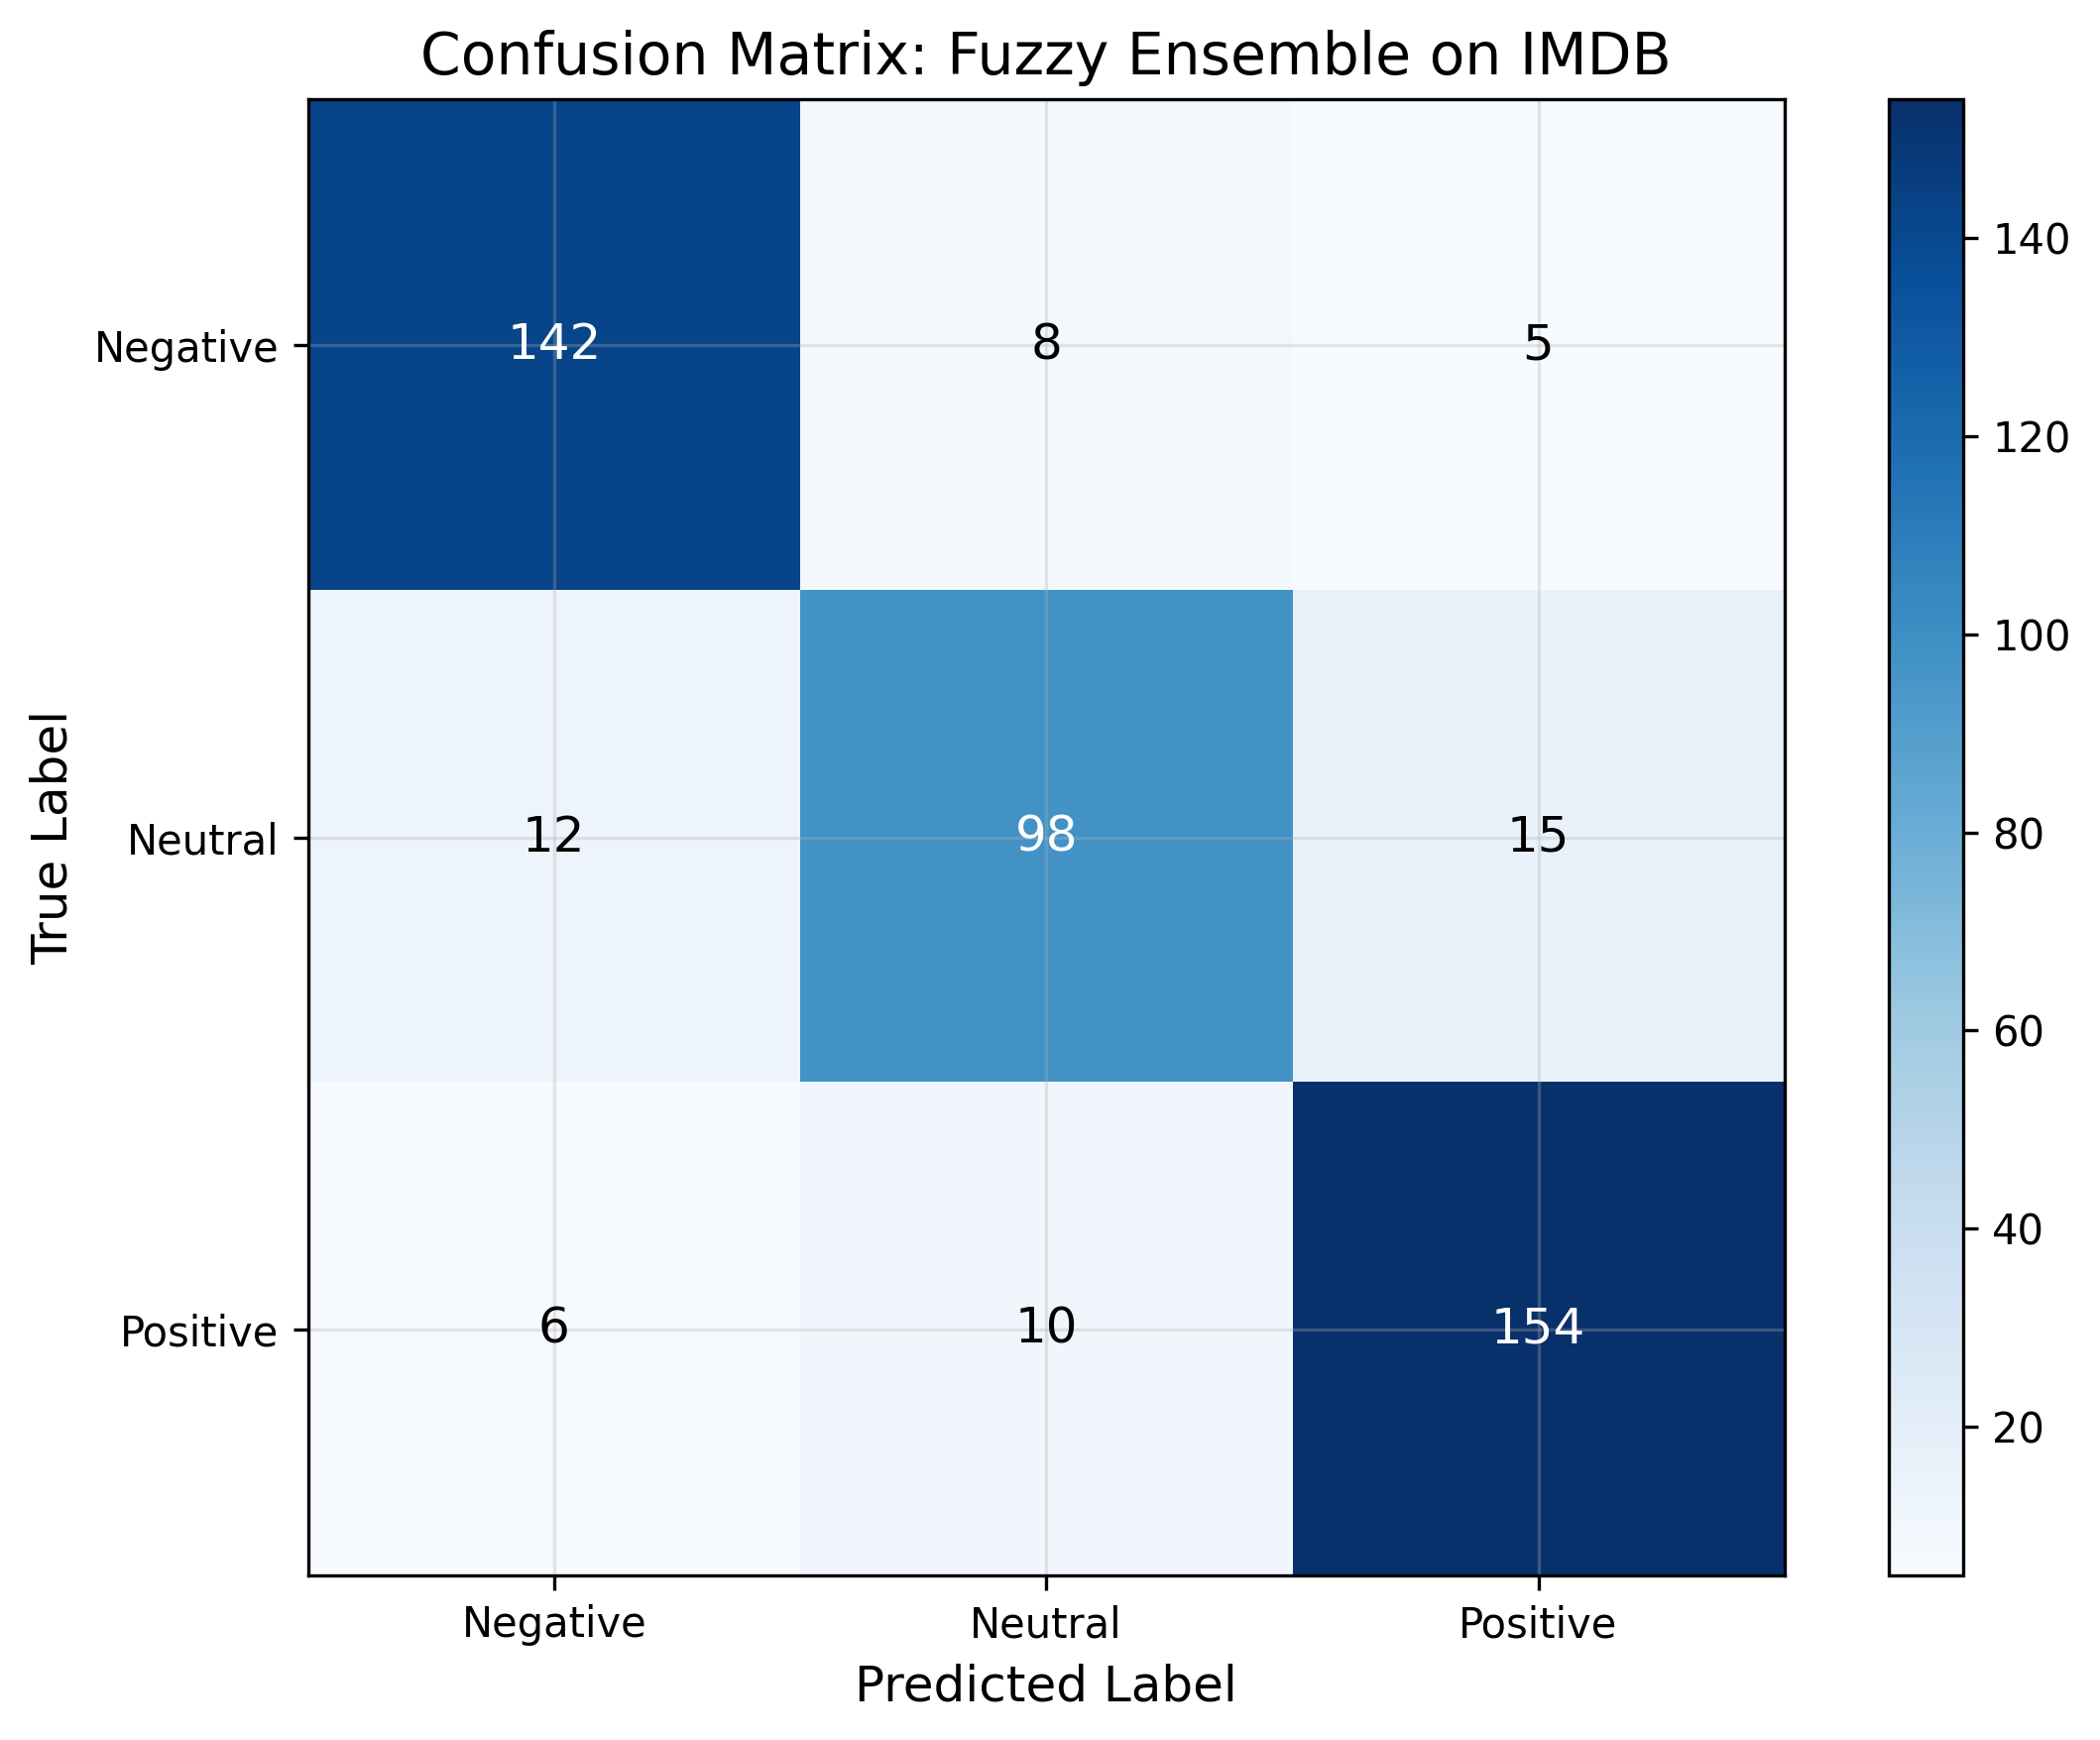

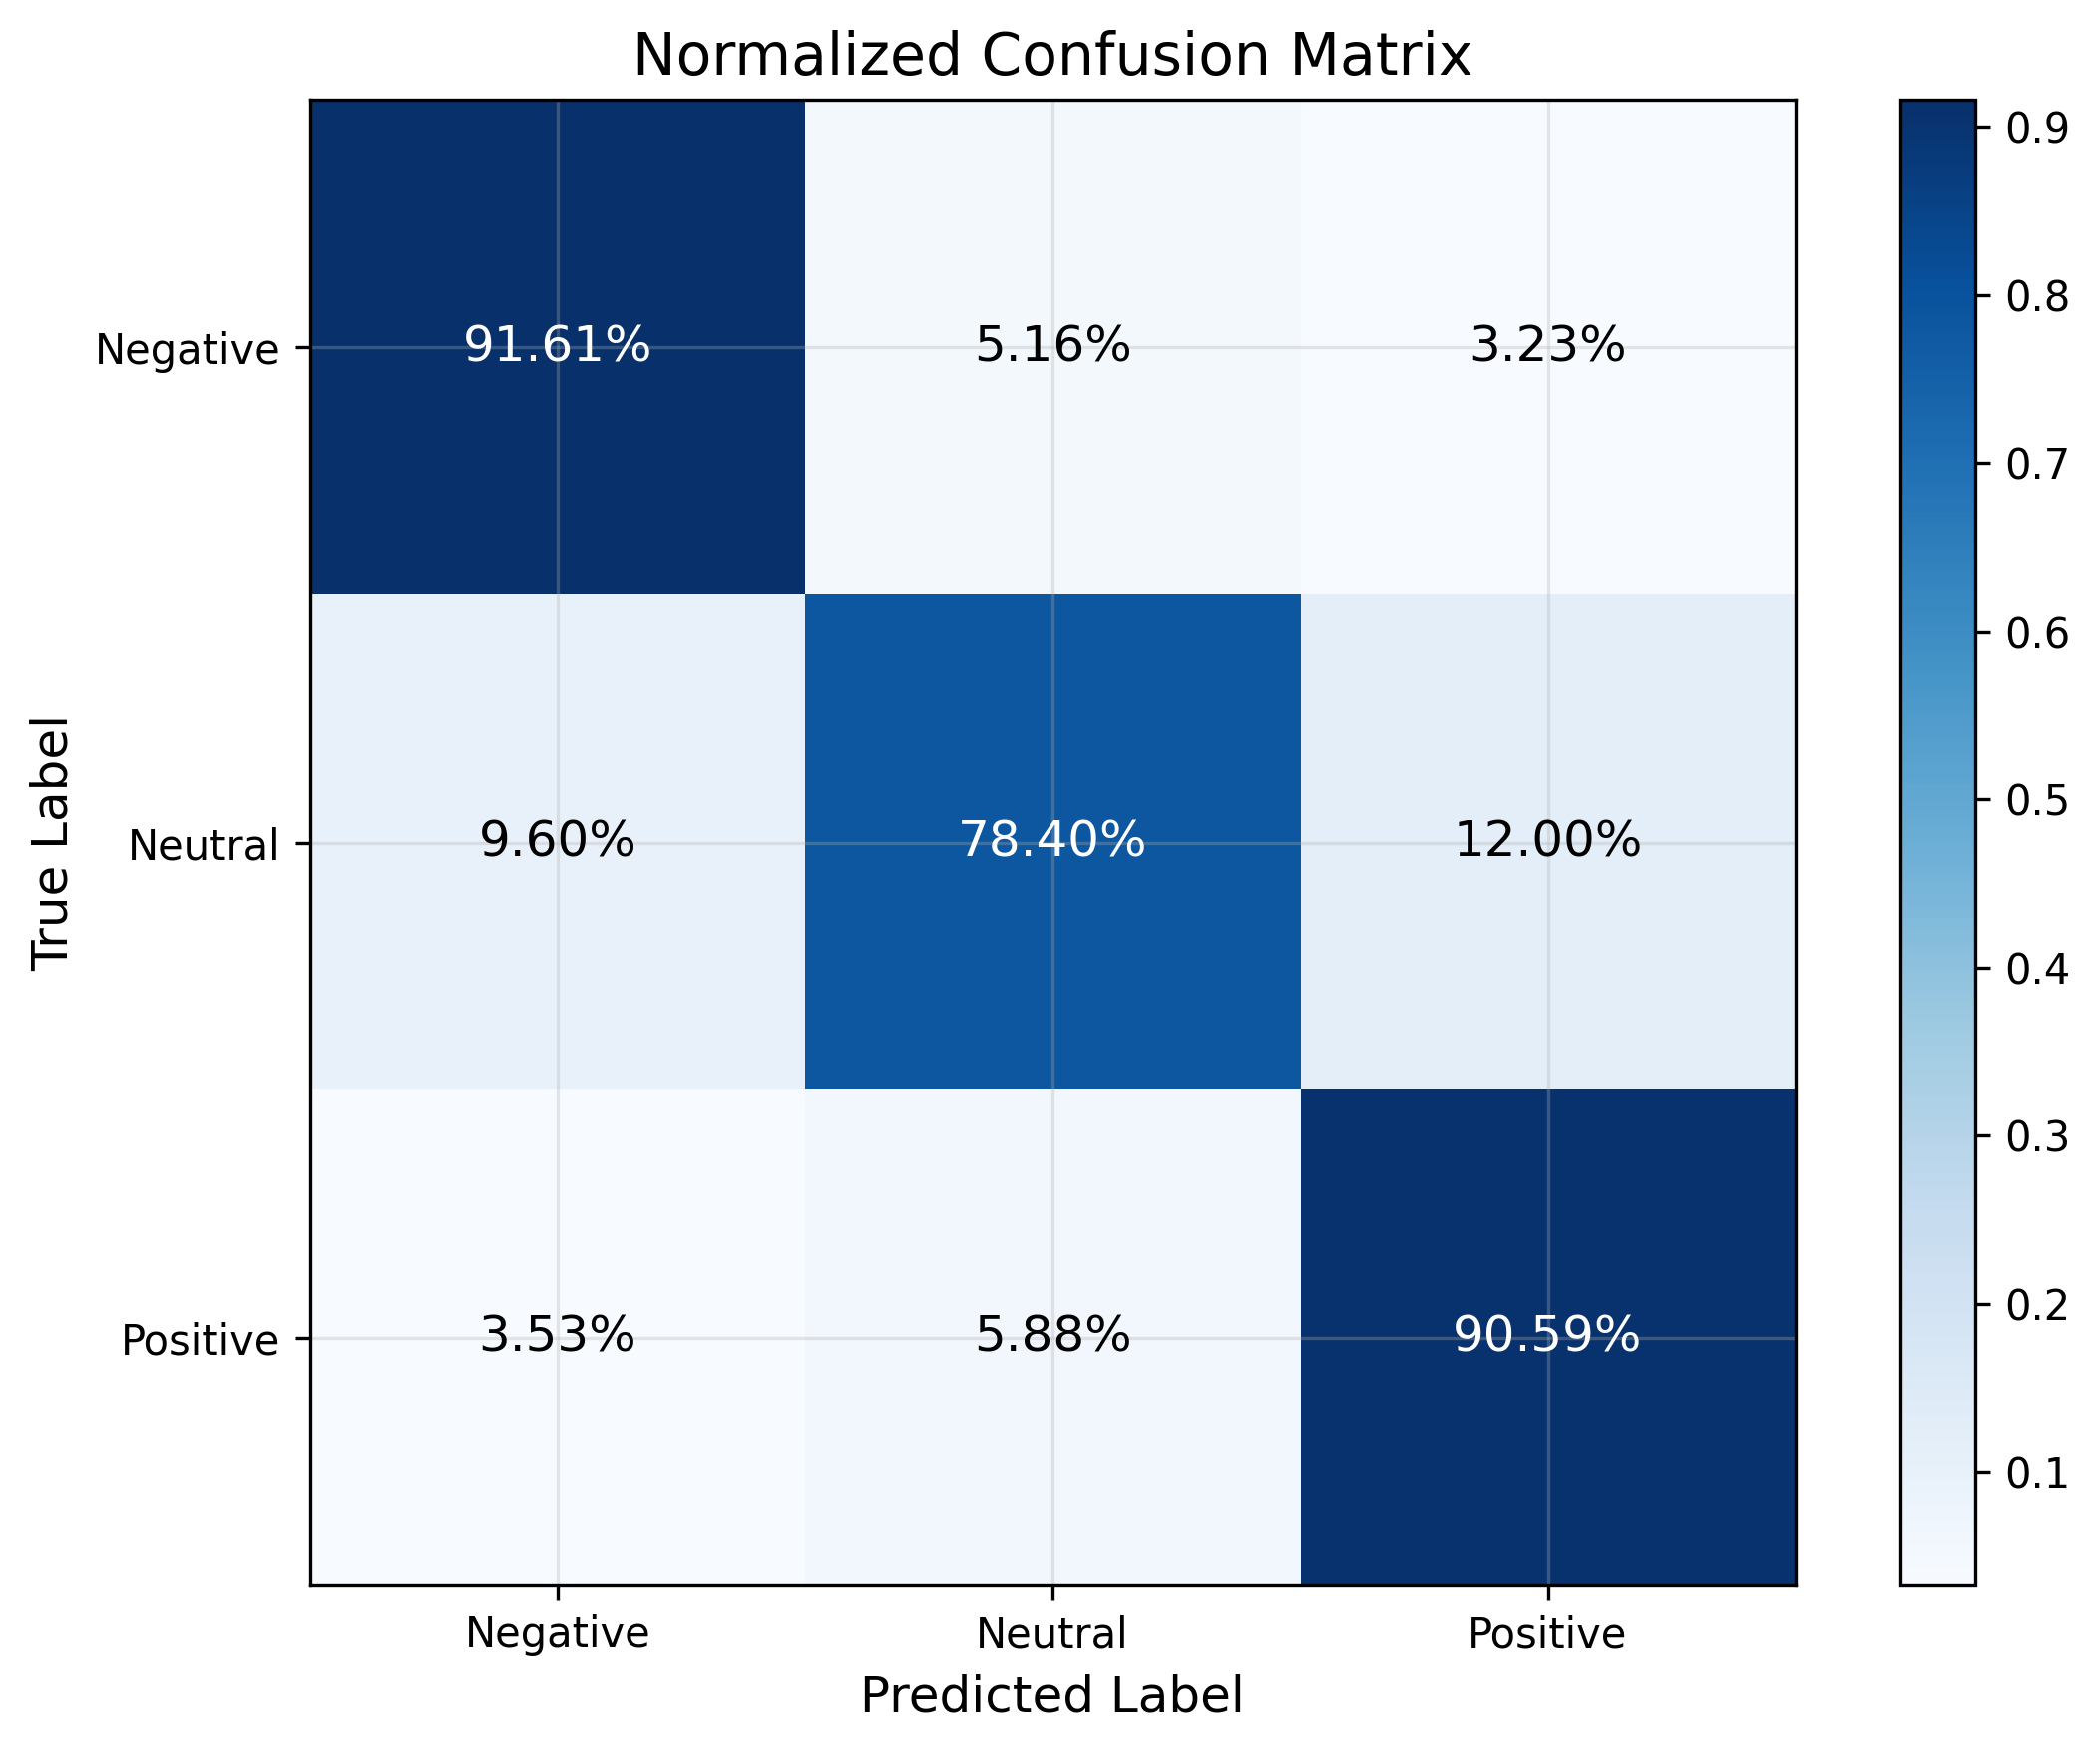

In [4]:
for name in ['confusion_matrix_logreg.png', 'confusion_matrix_svm.png',
             'confusion_matrix_ensemble.png', 'confusion_matrix.png',
             'confusion_matrix_normalized.png']:
    show_fig(name)

Raw confusion-matrix numbers (all models in one place): `backend/results/confusion_matrices/confusion_matrices.json`.

In [5]:
cm = load_json('confusion_matrices/confusion_matrices.json')
print('n_samples =', cm['n_samples'], ' label_order =', cm['label_order'])
for entry in cm['results']:
    print(f"\n{entry['model']}  (macro-F1={entry['macro_f1']})")
    display(pd.DataFrame(entry['confusion_matrix']['matrix'],
                          index=cm['label_order'], columns=cm['label_order']))

n_samples = 5000  label_order = ['Negative', 'Neutral', 'Positive']

logreg  (macro-F1=0.6909)


,Negative,Neutral,Positive
Negative,1312,351,161
Neutral,379,929,229
Positive,191,222,1226



svm  (macro-F1=0.6791)


,Negative,Neutral,Positive
Negative,1290,367,167
Neutral,375,916,246
Positive,201,236,1202



tfidf  (macro-F1=0.6545)


...

,Negative,Neutral,Positive
Negative,1322,342,160
Neutral,383,932,222
Positive,196,216,1227



meta_learner  (macro-F1=0.6964)


,Negative,Neutral,Positive
Negative,1279,380,165
Neutral,346,972,219
Positive,170,231,1238



fuzzy_ensemble  (macro-F1=0.6927)


,Negative,Neutral,Positive
Negative,1336,334,154
Neutral,396,922,219
Positive,205,215,1219


## 2.4 Calibration (ECE) — how trustworthy are the predicted probabilities?

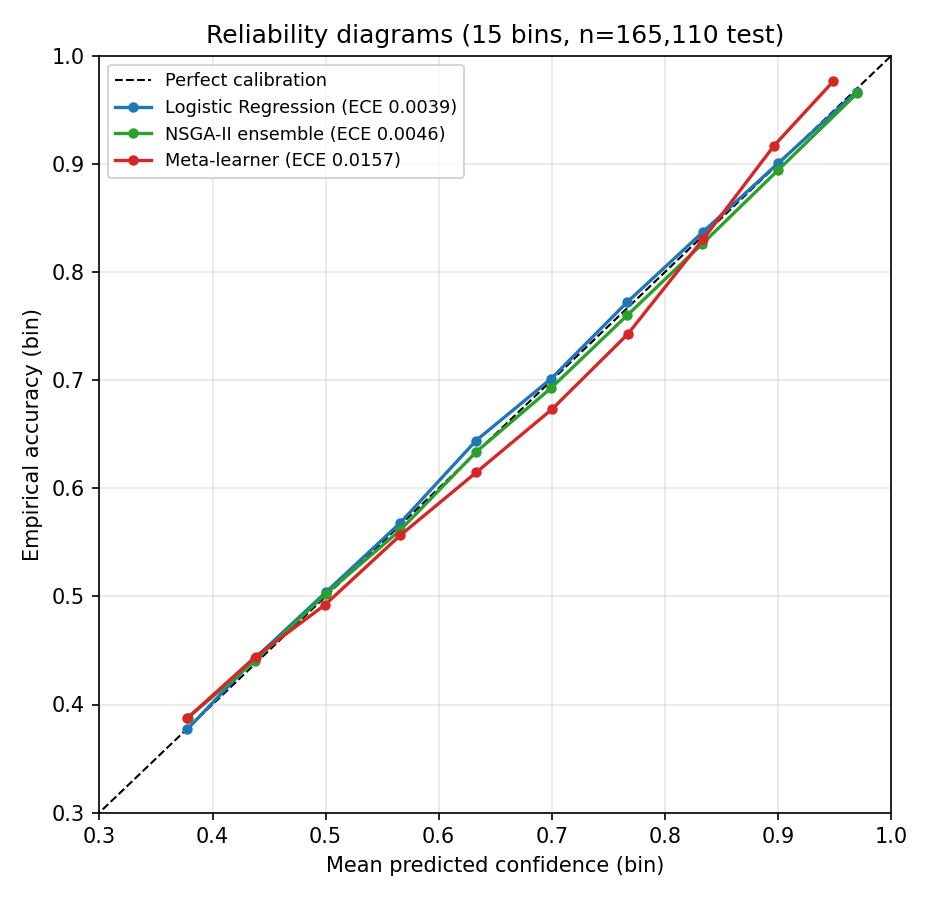

In [6]:
show_fig('reliability_diagrams.png')

## Notes

*(Add your own framing here: which baseline is the strongest single model, and why the ensemble does/doesn't beat it — this sets up the motivation for the optimisation work in notebook 03.)*